In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)
os.makedirs("sql", exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
import pandas as pd

data = {
    "Order_ID": range(1001, 1021),
    "Product": [
        "Laptop", "Mobile", "Headphones", "Keyboard", "Mouse",
        "Monitor", "Tablet", "Smartwatch", "Printer", "Camera",
        "Laptop", "Mobile", "Headphones", "Keyboard", "Mouse",
        "Monitor", "Tablet", "Smartwatch", "Printer", "Camera"
    ],
    "Category": [
        "Electronics", "Electronics", "Accessories", "Accessories", "Accessories",
        "Electronics", "Electronics", "Electronics", "Electronics", "Electronics",
        "Electronics", "Electronics", "Accessories", "Accessories", "Accessories",
        "Electronics", "Electronics", "Electronics", "Electronics", "Electronics"
    ],
    "Quantity": [
        2, 3, 5, 4, 6, 2, 3, 4, 2, 1,
        1, 4, 7, 3, 5, 2, 4, 3, 2, 2
    ],
    "Price": [
        55000, 25000, 2000, 1500, 800,
        12000, 30000, 8000, 15000, 45000,
        60000, 22000, 2500, 1800, 700,
        14000, 28000, 7500, 13000, 42000
    ],
    "Customer": [
        "Asha", "Rahul", "Priya", "Arjun", "Sneha",
        "Kiran", "Anu", "Ravi", "Meena", "Vikram",
        "Asha", "Rahul", "Priya", "Arjun", "Sneha",
        "Kiran", "Anu", "Ravi", "Meena", "Vikram"
    ],
    "City": [
        "Hyderabad", "Warangal", "Vijayawada", "Hyderabad", "Warangal",
        "Chennai", "Bangalore", "Hyderabad", "Pune", "Delhi",
        "Bangalore", "Chennai", "Hyderabad", "Warangal", "Pune",
        "Delhi", "Bangalore", "Hyderabad", "Chennai", "Pune"
    ]
}

df = pd.DataFrame(data)

# Calculate total sales
df["Total_Sales"] = df["Quantity"] * df["Price"]

# Save as CSV
df.to_csv("ecommerce_sales.csv", index=False)

print("ecommerce_sales.csv created successfully!")

ecommerce_sales.csv created successfully!


In [ ]:
import os

os.listdir()

['.config',
 'visualizations',
 'ecommerce_sales.csv',
 'data',
 'sql',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("ecommerce_sales.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,Order_ID,Product,Category,Quantity,Price,Customer,City,Total_Sales
0,1001,Laptop,Electronics,2,55000,Asha,Hyderabad,110000
1,1002,Mobile,Electronics,3,25000,Rahul,Warangal,75000
2,1003,Headphones,Accessories,5,2000,Priya,Vijayawada,10000
3,1004,Keyboard,Accessories,4,1500,Arjun,Hyderabad,6000
4,1005,Mouse,Accessories,6,800,Sneha,Warangal,4800


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (20, 8)


In [ ]:
print(df.columns.tolist())

['Order_ID', 'Product', 'Category', 'Quantity', 'Price', 'Customer', 'City', 'Total_Sales']


In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
Order_ID        int64
Product        object
Category       object
Quantity        int64
Price           int64
Customer       object
City           object
Total_Sales     int64
dtype: object


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID       0
Product        0
Category       0
Quantity       0
Price          0
Customer       0
City           0
Total_Sales    0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.describe()

,Order_ID,Quantity,Price,Total_Sales
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,3.250000,19290.000000,43685.000000
std,5.91608,1.618154,18688.637133,36706.062528
min,1001.00000,1.000000,700.000000,3500.000000
25%,1005.75000,2.000000,2375.000000,15625.000000
50%,1010.50000,3.000000,13500.000000,29000.000000
75%,1015.25000,4.000000,28500.000000,77250.000000
max,1020.00000,7.000000,60000.000000,112000.000000


In [ ]:
print("Sales Statistics")
print("-----------------")
print("Total Sales:", df["Total_Sales"].sum())
print("Average Sales:", df["Total_Sales"].mean())
print("Maximum Sales:", df["Total_Sales"].max())
print("Minimum Sales:", df["Total_Sales"].min())

Sales Statistics
-----------------
Total Sales: 873700
Average Sales: 43685.0
Maximum Sales: 112000
Minimum Sales: 3500


In [ ]:
total_sales = df["Total_Sales"].sum()
total_quantity = df["Quantity"].sum()
average_order_value = df["Total_Sales"].mean()

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 873700
Total Quantity Sold: 65
Average Order Value: 43685.0


In [ ]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

print(product_sales)

Product
Camera        129000
Headphones     27500
Keyboard       11400
Laptop        170000
Mobile        163000
Monitor        52000
Mouse           8300
Printer        56000
Smartwatch     54500
Tablet        202000
Name: Total_Sales, dtype: int64


In [ ]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Best Product:", best_product)
print("Sales:", best_product_sales)

Best Product: Tablet
Sales: 202000


In [ ]:
product_quantity = df.groupby("Product")["Quantity"].sum()

product_quantity = product_quantity.sort_values(ascending=False)

print(product_quantity)

Product
Headphones    12
Mouse         11
Tablet         7
Keyboard       7
Smartwatch     7
Mobile         7
Printer        4
Monitor        4
Camera         3
Laptop         3
Name: Quantity, dtype: int64


In [ ]:
category_sales = df.groupby("Category")["Total_Sales"].sum()

category_sales = category_sales.sort_values(ascending=False)

print(category_sales)

Category
Electronics    826500
Accessories     47200
Name: Total_Sales, dtype: int64


In [ ]:
best_category = category_sales.idxmax()

print("Best Category:", best_category)

Best Category: Electronics


In [ ]:
category_quantity = df.groupby("Category")["Quantity"].sum()

print(category_quantity)

Category
Accessories    30
Electronics    35
Name: Quantity, dtype: int64


In [ ]:
city_sales = df.groupby("City")["Total_Sales"].sum()

city_sales = city_sales.sort_values(ascending=False)

print(city_sales)

City
Bangalore     262000
Hyderabad     188000
Chennai       138000
Pune          117500
Warangal       85200
Delhi          73000
Vijayawada     10000
Name: Total_Sales, dtype: int64


In [ ]:
best_city = city_sales.idxmax()

print("Best Performing City:", best_city)

Best Performing City: Bangalore


In [ ]:
city_quantity = df.groupby("City")["Quantity"].sum()

city_quantity = city_quantity.sort_values(ascending=False)

print(city_quantity)

City
Hyderabad     20
Warangal      12
Pune           9
Bangalore      8
Chennai        8
Vijayawada     5
Delhi          3
Name: Quantity, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

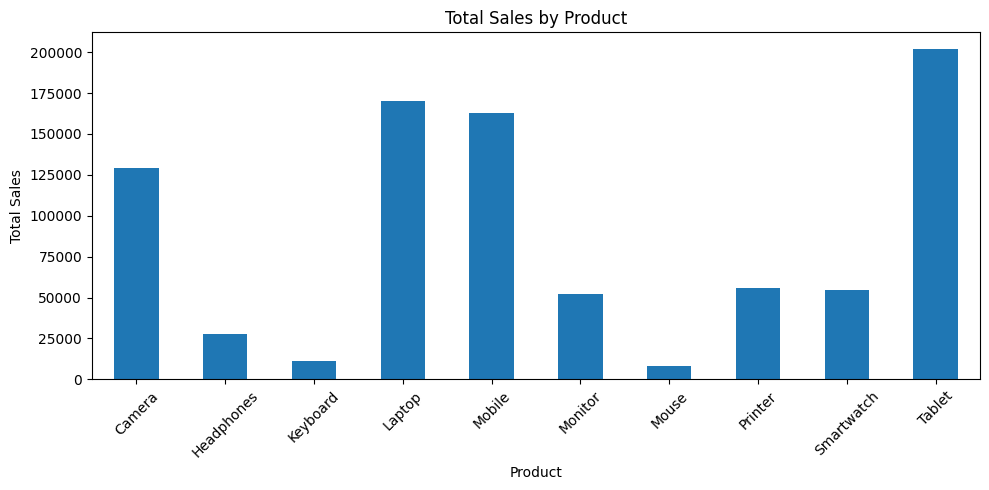

In [ ]:
plt.figure(figsize=(10,5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

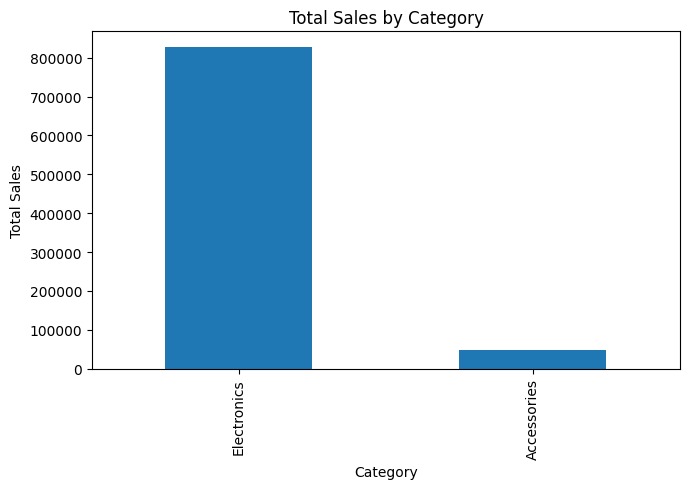

In [ ]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

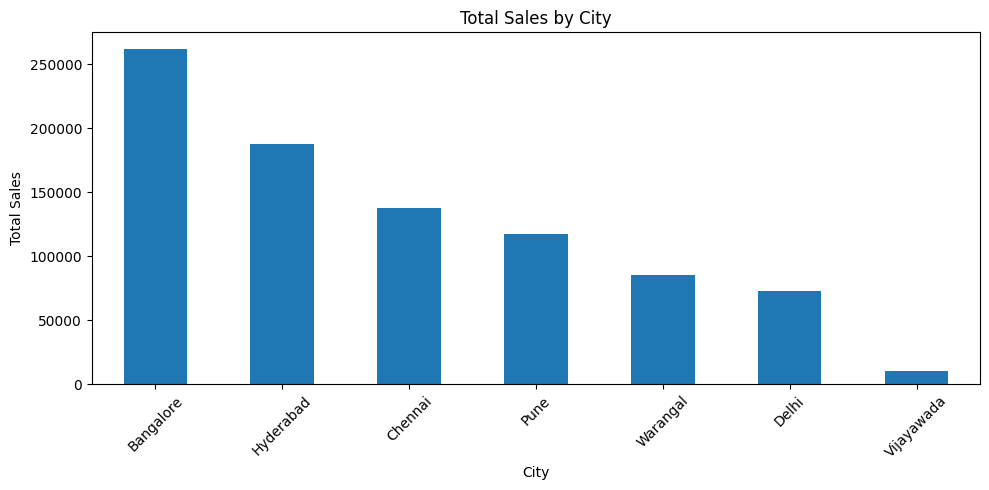

In [ ]:
plt.figure(figsize=(10,5))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

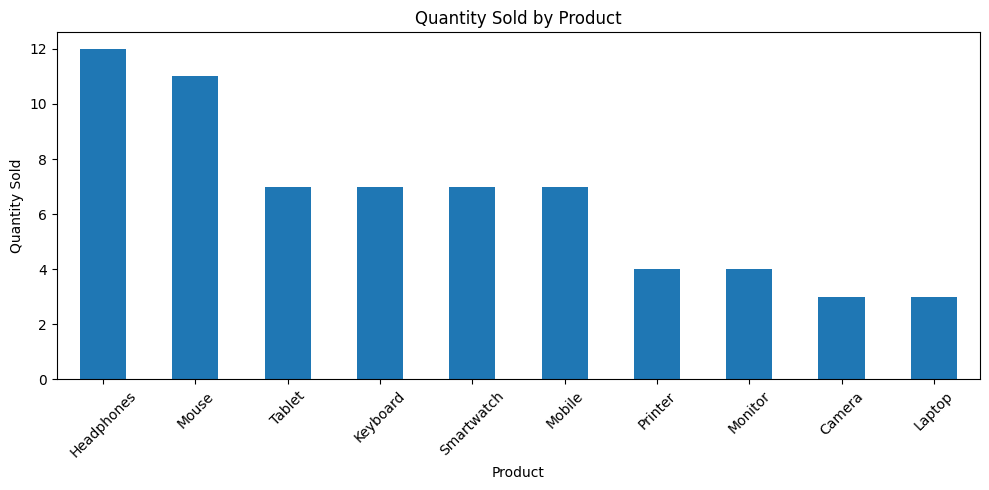

In [ ]:
plt.figure(figsize=(10,5))

product_quantity.plot(kind="bar")

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

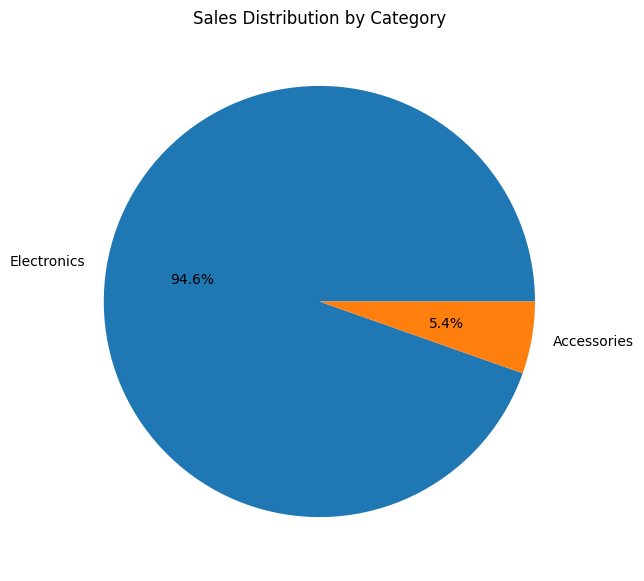

In [ ]:
plt.figure(figsize=(7,7))

category_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Category")
plt.ylabel("")

plt.show()

In [ ]:
import os

os.makedirs("visualizations", exist_ok=True)

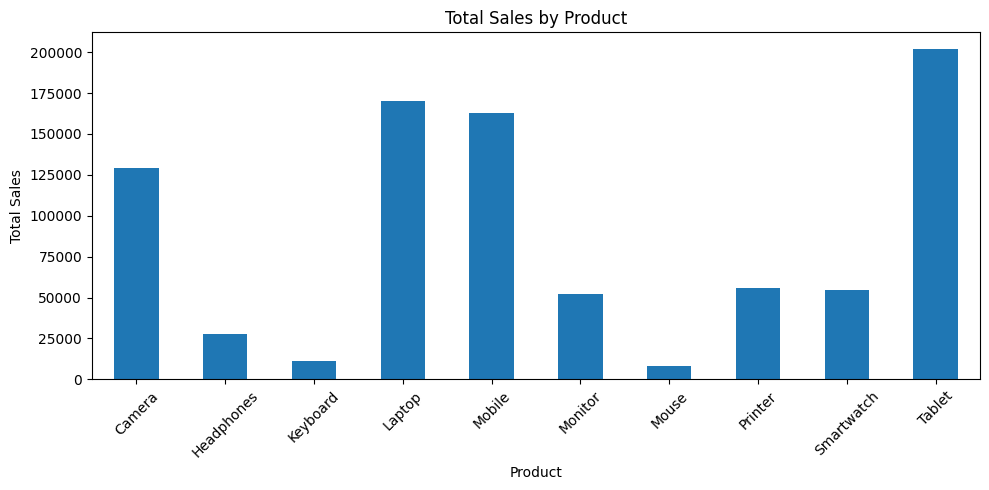

In [ ]:
plt.figure(figsize=(10,5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("visualizations/sales_by_product.png")
plt.show()

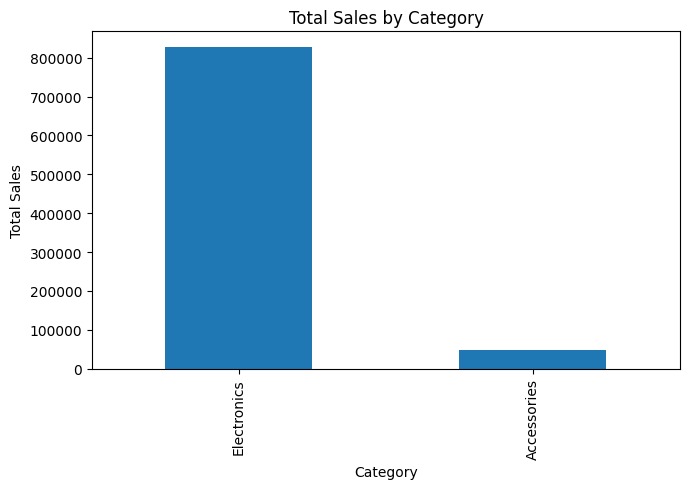

In [ ]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig("visualizations/sales_by_category.png")
plt.show()

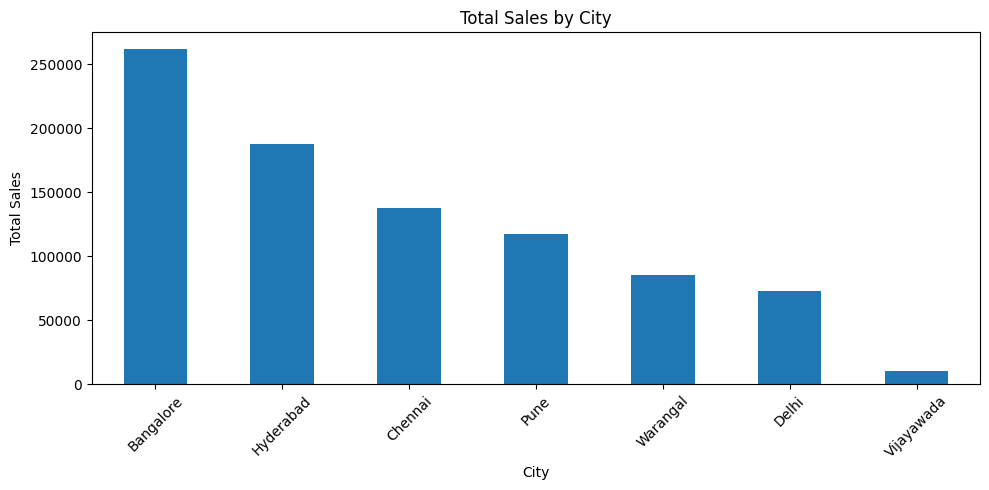

In [ ]:
plt.figure(figsize=(10,5))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("visualizations/sales_by_city.png")
plt.show()

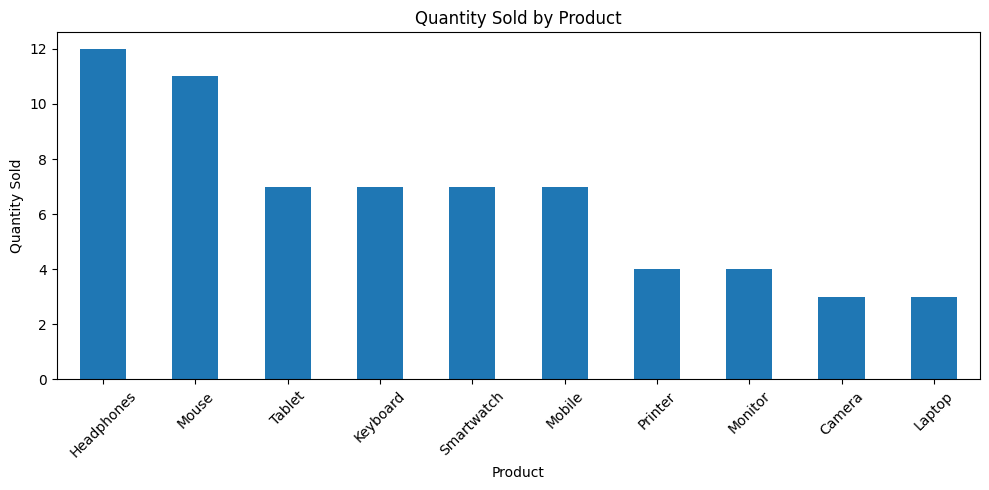

In [ ]:
plt.figure(figsize=(10,5))

product_quantity.plot(kind="bar")

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("visualizations/quantity_by_product.png")
plt.show()

In [ ]:
print("===== E-COMMERCE SALES INSIGHTS =====")

print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))

print("Best Product:", best_product)
print("Best Category:", best_category)
print("Best City:", best_city)

===== E-COMMERCE SALES INSIGHTS =====
Total Sales: 873700
Total Quantity Sold: 65
Average Order Value: 43685.0
Best Product: Tablet
Best Category: Electronics
Best City: Bangalore


In [ ]:
sql_code = """
-- E-Commerce Sales Analysis

-- 1. View all orders
SELECT *
FROM ecommerce_sales;

-- 2. Total sales
SELECT SUM(Total_Sales) AS Total_Sales
FROM ecommerce_sales;

-- 3. Total quantity sold
SELECT SUM(Quantity) AS Total_Quantity
FROM ecommerce_sales;

-- 4. Average order value
SELECT AVG(Total_Sales) AS Average_Order_Value
FROM ecommerce_sales;

-- 5. Sales by product
SELECT Product,
       SUM(Total_Sales) AS Total_Sales
FROM ecommerce_sales
GROUP BY Product
ORDER BY Total_Sales DESC;

-- 6. Sales by category
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM ecommerce_sales
GROUP BY Category
ORDER BY Total_Sales DESC;

-- 7. Sales by city
SELECT City,
       SUM(Total_Sales) AS Total_Sales
FROM ecommerce_sales
GROUP BY City
ORDER BY Total_Sales DESC;

-- 8. Quantity sold by product
SELECT Product,
       SUM(Quantity) AS Total_Quantity
FROM ecommerce_sales
GROUP BY Product
ORDER BY Total_Quantity DESC;
"""

with open("analysis.sql", "w") as file:
    file.write(sql_code)

print("analysis.sql created successfully!")

analysis.sql created successfully!


In [ ]:
import shutil

shutil.move("analysis.sql", "sql/analysis.sql")

print("SQL file moved to sql folder!")

SQL file moved to sql folder!


In [ ]:
df.describe()

,Order_ID,Quantity,Price,Total_Sales
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,3.250000,19290.000000,43685.000000
std,5.91608,1.618154,18688.637133,36706.062528
min,1001.00000,1.000000,700.000000,3500.000000
25%,1005.75000,2.000000,2375.000000,15625.000000
50%,1010.50000,3.000000,13500.000000,29000.000000
75%,1015.25000,4.000000,28500.000000,77250.000000
max,1020.00000,7.000000,60000.000000,112000.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     20 non-null     int64 
 1   Product      20 non-null     object
 2   Category     20 non-null     object
 3   Quantity     20 non-null     int64 
 4   Price        20 non-null     int64 
 5   Customer     20 non-null     object
 6   City         20 non-null     object
 7   Total_Sales  20 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 1.4+ KB


In [ ]:
total_sales = df["Total_Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 873700


In [ ]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 65


In [ ]:
average_order_value = df["Total_Sales"].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 43685.0


In [ ]:
print("===== E-COMMERCE SALES SUMMARY =====")
print("Total Sales:", total_sales)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))

===== E-COMMERCE SALES SUMMARY =====
Total Sales: 873700
Total Quantity Sold: 65
Average Order Value: 43685.0


In [ ]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

product_sales = product_sales.sort_values(ascending=False)

print(product_sales)

Product
Tablet        202000
Laptop        170000
Mobile        163000
Camera        129000
Printer        56000
Smartwatch     54500
Monitor        52000
Headphones     27500
Keyboard       11400
Mouse           8300
Name: Total_Sales, dtype: int64


In [ ]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Best-Selling Product:", best_product)
print("Sales:", best_product_sales)

Best-Selling Product: Tablet
Sales: 202000


In [ ]:
product_quantity = df.groupby("Product")["Quantity"].sum()

product_quantity = product_quantity.sort_values(ascending=False)

print(product_quantity)

Product
Headphones    12
Mouse         11
Tablet         7
Keyboard       7
Smartwatch     7
Mobile         7
Printer        4
Monitor        4
Camera         3
Laptop         3
Name: Quantity, dtype: int64


In [ ]:
category_sales = df.groupby("Category")["Total_Sales"].sum()

category_sales = category_sales.sort_values(ascending=False)

print(category_sales)

Category
Electronics    826500
Accessories     47200
Name: Total_Sales, dtype: int64


In [ ]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Best Category:", best_category)
print("Sales:", best_category_sales)

Best Category: Electronics
Sales: 826500


In [ ]:
category_quantity = df.groupby("Category")["Quantity"].sum()

category_quantity = category_quantity.sort_values(ascending=False)

print(category_quantity)

Category
Electronics    35
Accessories    30
Name: Quantity, dtype: int64


In [ ]:
city_sales = df.groupby("City")["Total_Sales"].sum()

city_sales = city_sales.sort_values(ascending=False)

print(city_sales)

City
Bangalore     262000
Hyderabad     188000
Chennai       138000
Pune          117500
Warangal       85200
Delhi          73000
Vijayawada     10000
Name: Total_Sales, dtype: int64


In [ ]:
best_city = city_sales.idxmax()
best_city_sales = city_sales.max()

print("Best Performing City:", best_city)
print("Sales:", best_city_sales)

Best Performing City: Bangalore
Sales: 262000


In [ ]:
city_quantity = df.groupby("City")["Quantity"].sum()

city_quantity = city_quantity.sort_values(ascending=False)

print(city_quantity)

City
Hyderabad     20
Warangal      12
Pune           9
Bangalore      8
Chennai        8
Vijayawada     5
Delhi          3
Name: Quantity, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
requirements = """pandas
numpy
matplotlib
seaborn
jupyter
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [ ]:
gitignore = """__pycache__/
.ipynb_checkpoints/
*.pyc
.env
"""

with open(".gitignore", "w") as file:
    file.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!


In [ ]:
readme = """# E-Commerce Sales Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on an e-commerce sales dataset to identify sales trends, best-selling products, category performance, and city-wise sales.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Google Colab

## Analysis Performed

- Dataset exploration
- Data cleaning and validation
- Statistical analysis
- Product-wise sales analysis
- Category-wise sales analysis
- City-wise sales analysis
- Sales visualizations
- Business insights
- SQL analysis

## Key Metrics

- Total Sales
- Total Quantity Sold
- Average Order Value
- Best-Selling Product
- Best Category
- Best Performing City

## Project Structure

ECommerce_Sales_EDA/
- data/
- notebooks/
- sql/
- visualizations/
- README.md
- requirements.txt
- .gitignore
"""

with open("README.md", "w") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
gitignore = """__pycache__/
.ipynb_checkpoints/
*.pyc
.env
"""

with open(".gitignore", "w") as file:
    file.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!


In [65]:
gitignore = """__pycache__/
.ipynb_checkpoints/
*.pyc
.env
"""

with open(".gitignore", "w") as file:
    file.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!


In [69]:
gitignore = """__pycache__/
.ipynb_checkpoints/
*.pyc
.env
"""

with open(".gitignore", "w") as file:
    file.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!
